#**Final Project**

Iris Wu

Data 201

Spring 2026

##**Introduction**


Since May is Mental Health Awareness Month, for this project, I trained three decision tree models to predict depression prevalence rates in DC, Maryland, and Virginia. I initially wanted to focus on Maryland, but I could not find a sufficiently large dataset. Instead, I used filtering to create a DMV subset from the PLACES county-level dataset. Each year, the Centers for Disease Control and Prevention (CDC) releases PLACES data, which estimates health outcomes at different geographic levels across the US. PLACES data is derived from the Behavioral Risk Factor Surveillance System and the US Census Bureau's American Community Survey. I used the 2025 release of PLACES, which covers 2022 and 2023 data. For consistency and recency purposes, I only looked at 2023 data.

In this project, I wanted to determine which environmental and health-related risk factors correlated with depression prevalence rates in DMV counties in 2023. Are external factors like housing or food insecurity good predictors of the depression prevalence rate? What is the relationship between physical health and mental health? To answer these questions, I chose seven variables that I thought would most likely correlate with depression and tested them with my decison tree models.

Although the original PLACES dataset has over 200,000 observations, my DMV subset had fewer than 1,000 rows. I used a 70/30 train-test split to ensure sufficient test data, but the small sample size limited the robustness of my models. Even so, I was able to compare and evaluate six decision tree models and draw insights on the strongest predictors of depression prevalence rates across DMV counties in 2023.


Data Citation: Centers for Disease Control and Prevention. PLACES: Local Data for Better Health. Accessed May 13, 2026. https://data.cdc.gov/500-Cities-Places/PLACES-Local-Data-for-Better-Health-County-Data-20/swc5-untb/about_data

##**Dataset Overview and Preparation**

In [1]:
#install kaleido to show interactive plot on github
!pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 12.8 MB/s eta 0:00:00


In [2]:
#Load the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import kaleido
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score




In [3]:
#Load the dataset
from google.colab import drive
drive.mount('/content/drive')


df_health = pd.read_csv("/content/drive/MyDrive/PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260513.csv", encoding= "latin1")
df_health.head()


Mounted at /content/drive


/tmp/ipykernel_2946/1667819902.py:6: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df_health = pd.read_csv("/content/drive/MyDrive/PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260513.csv", encoding= "latin1")


,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
0,2023,AR,Arkansas,Drew,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,29.9,...,26.6,33.3,"16,945","13,230",5043,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-91.7196579038053 33.5894113647675)
1,2023,AR,Arkansas,Fulton,BRFSS,Health Outcomes,Current asthma among adults,%,Crude prevalence,10.6,...,9.2,11.9,"12,421","9,795",5049,HLTHOUT,CASTHMA,CrdPrv,Current Asthma,POINT (-91.817888079321 36.3816206347765)
2,2023,AR,Arkansas,Howard,BRFSS,Health Outcomes,Arthritis among adults,%,Crude prevalence,31.2,...,27.7,34.8,"12,533","9,311",5061,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,POINT (-93.9938053308515 34.0889044688856)
3,2023,AR,Arkansas,Miller,BRFSS,Health Outcomes,Stroke among adults,%,Crude prevalence,4.7,...,4.2,5.3,"42,415","32,396",5091,HLTHOUT,STROKE,CrdPrv,Stroke,POINT (-93.8924281761086 33.3123156126392)
4,2023,AR,Arkansas,Ouachita,BRFSS,Disability,Any disability among adults,%,Crude prevalence,42.8,...,37.9,47.8,"21,793","16,948",5103,DISABLT,DISABILITY,CrdPrv,Any Disability,POINT (-92.882040791321 33.593253927504)


In [4]:
#Size of dataset
rows, columns = df_health.shape
print(f"The dataset has {rows} rows and {columns} columns")


The dataset has 229298 rows and 22 columns


###**Relevant Variables**

For this project, I examined the following age-adjusted prevalence measurements for the following health factors. I chose age-adjusted prevalence instead of crude prevalence because the former controls for age distribution, so comparisons across locations are more reliable.














**Features**


| Feature                                                            | Data ID    |
|--------------------------------------------------------------------|------------|
| Loneliness among adults                                            | LONELINESS |
| Housing insecurity in the past 12 months among adults              | HOUSINSECU |
| Food insecurity in the past 12 months among adults                 | FOODINSECU |
| Lack of social and emotional support among adults                  | EMOTIONSPT   |
| Frequent physical distress among adults                            | PHLTH      |
| No leisure time/physical activity among adults                     | LPA        |
| Lack of reliable transportation in the past 12 months among adults | LACKTRPT   |
|      |            |



**Target Variable**


*   Depression among adults (DEPRESSION)



###**Data Cleaning**

In this project, I only examined 2023 data from DC, Maryland, and Virginia. To prepare the dataset for the decision tree models, I then filtered for the relevant feature and target variables. I also converted the dataset to wide format for readability.

In [5]:
#filter for state, year, age-adjusted prevelance, feature and target variables
features = ["LONELINESS", "HOUSINSECU","FOODINSECU", "EMOTIONSPT", "PHLTH", "LPA", "LACKTRPT", "DEPRESSION" ]

df_dmv = (df_health[
    (df_health["StateAbbr"].isin(["MD", "VA", "DC"])) &
    (df_health["Year"] == 2023) &
    (df_health["Data_Value_Type"] == "Age-adjusted prevalence") &
    (df_health["MeasureId"].isin(features))])

#pivot to wide format
df_wide = df_dmv.pivot_table(index=["StateAbbr", "LocationName"], columns = "Measure", values="Data_Value").reset_index()
df_wide.head()


Measure,StateAbbr,LocationName,Depression among adults,Food insecurity in the past 12 months among adults,Frequent physical distress among adults,Housing insecurity in the past 12 months among adults,Lack of reliable transportation in the past 12 months among adults,Lack of social and emotional support among adults,Loneliness among adults,No leisure-time physical activity among adults
0,DC,District of Columbia,21.0,13.8,9.6,12.00,7.8,22.7,36.2,15.30
1,MD,Allegany,26.6,19.3,14.6,15.30,9.4,25.9,36.1,30.70
2,MD,Anne Arundel,20.4,11.9,11.0,10.90,6.3,22.5,34.2,19.80
3,MD,Baltimore,22.5,20.9,12.3,18.45,10.7,27.5,38.2,26.25
4,MD,Calvert,20.5,10.9,11.1,10.70,6.2,22.0,33.9,18.80


##**Exploratory Data Analysis**

###**Plot 1: Correlation Between Depression and Loneliness in Maryland**

In [8]:
#filter for MD, "DEPRESSION", "LONELINESS"
df_md = df_wide[df_wide["StateAbbr"] == "MD"][["StateAbbr", "LocationName", "Depression among adults", "Loneliness among adults"]]

#plot the data
fig = px.scatter(df_md, x="Loneliness among adults", y="Depression among adults",
                 hover_name="LocationName",
                 title="Depression and Loneliness among Adults in MD Counties, 2023",
                 labels={"Loneliness among adults": "Prevalence of Loneliness (%)",
                         "Depression among adults": "Prevalence of Depression (%)"})
fig.add_annotation(text="Source: CDC PLACES", xref="paper", yref="paper",
                   x=0.5, y=-0.2, showarrow=False)
fig.show()
fig.write_image("md.png")


I expected that higher loneliness prevalence would correspond to higher depression prevelance, since social isolation is closely associated with depression. However, the plot shows that there is no correlation between the two. In fact, in most counties, like Montgomery County, loneliness rates are  higher than depression rates. The lack of correlation could be due to the small sample size. Another explanation may be that loneliness is usually a temporary feeling, while depression is a medical condition that requires a diagnosis. Many people can feel lonely, but they likely do not have depression diagnoses at the same time.

###**Plot 2: Food Insecurity in Maryland and Virginia**

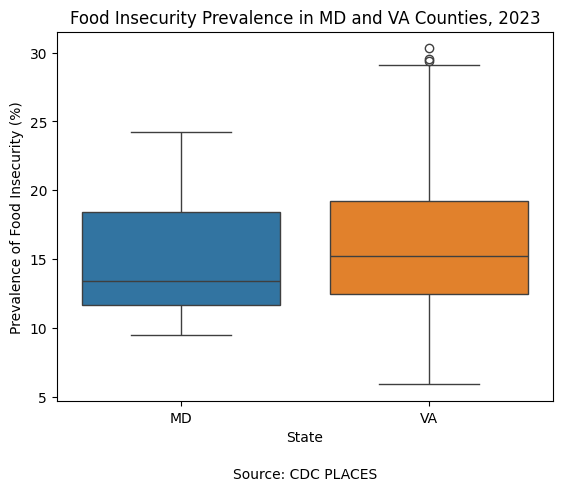

In [9]:
#filter for food insecurity
df_food = df_wide[df_wide["StateAbbr"].isin(["MD", "VA"])][["StateAbbr", "LocationName", "Food insecurity in the past 12 months among adults"]]

#plot the data
sns.boxplot(data = df_food, x = "StateAbbr", y = "Food insecurity in the past 12 months among adults", hue = "StateAbbr")
plt.title("Food Insecurity Prevalence in MD and VA Counties, 2023")
plt.xlabel("State")
plt.ylabel("Prevalence of Food Insecurity (%)")
plt.figtext(0.4, -0.05, "Source: CDC PLACES")
plt.show()

Prevalence of food insecurity is higher in Virginia than Maryland. Virginia also has a few counties that are outliers, with nearly food insecurity prevalence nearing 30%.

##**Decision Tree Analysis**

Since I have a small number of observations, I used a 70/30 train-test split to preserve more test data.

In [10]:
#Train/Test split
X = df_wide[["Loneliness among adults",
             "Food insecurity in the past 12 months among adults",
             "Lack of social and emotional support among adults",
             "Frequent physical distress among adults",
             "Lack of reliable transportation in the past 12 months among adults",
             "Housing insecurity in the past 12 months among adults",
             "No leisure-time physical activity among adults"]]  #predictors
y = df_wide["Depression among adults"]  #target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


###**Shallow Tree**

In [11]:
tree_shallow = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_shallow.fit(X_train, y_train)

y_pred_shallow = tree_shallow.predict(X_test)

print("Shallow Tree MSE:", mean_squared_error(y_test, y_pred_shallow))
print("Shallow Tree R2:", r2_score(y_test, y_pred_shallow))


Shallow Tree MSE: 2.515923198332017
Shallow Tree R2: 0.571449996555017


Around 57% of the variance in depression prevalence rates can be explained by the shallow decision tree.

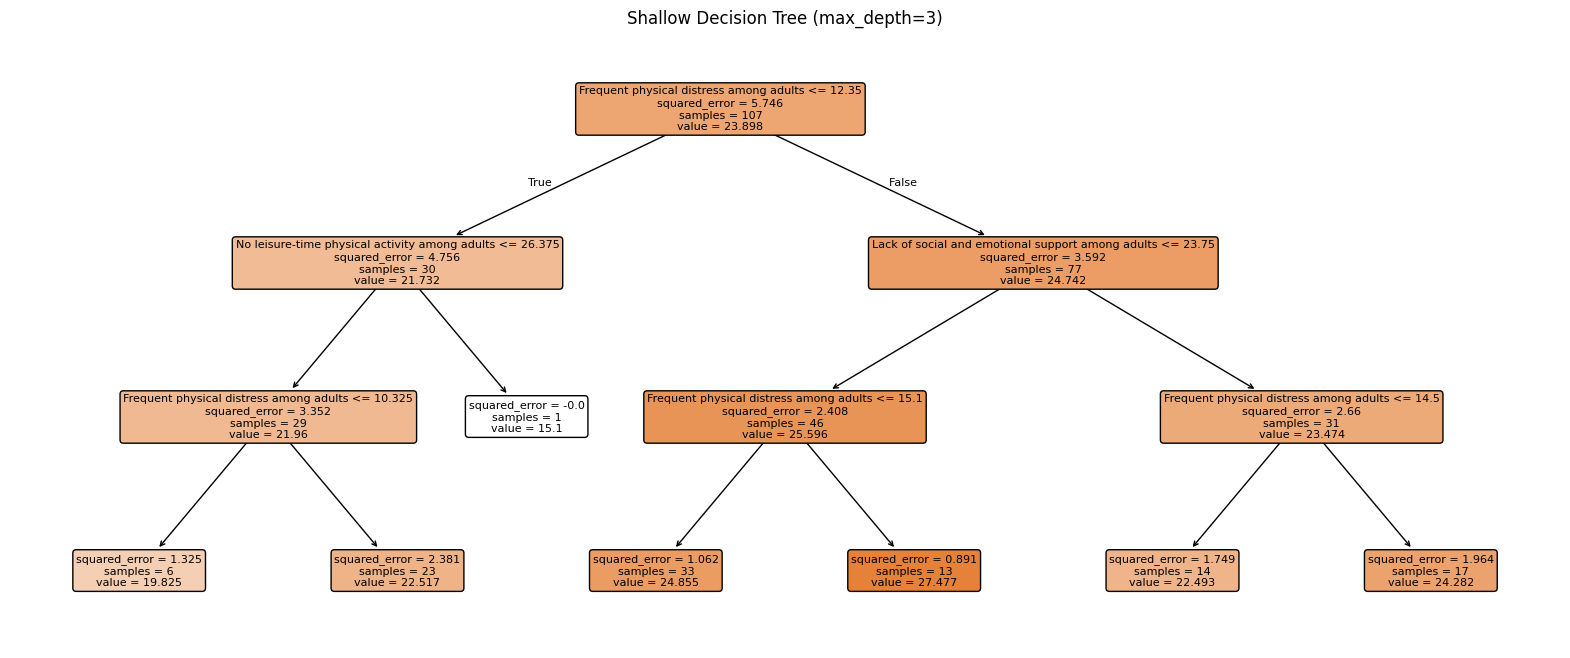

In [12]:
#plot the tree
plt.figure(figsize=(20, 8))
plot_tree(tree_shallow, feature_names=X.columns.tolist(), filled=True, rounded=True, fontsize=8)
plt.title("Shallow Decision Tree (max_depth=3)")
plt.show()

The root node asks whether the prevalence of frequent physical distress among adults in a county is less than or equal to 12.35%.


*   If true, then the tree asks whether no leisure time physical activity among adults is less than or equal to 26.375%. 33 counties are sorted into that node. If the tree stopped splitting there, it would predict a 21.732% depression prevalence for those 33 counties.
*  If false, then the tree asks whether lack of social and emotional support among adults is less than or equal to 23.75%. 77 counties are sorted into that node. If the tree stopped splitting there, it would predict 21.732% depression prevalence for those counties.

The shallow tree predicts that if frequent physical distress is less than or equal to 12.35% and no leisure time physical activity is less than 26.375%, then the depression prevalence rate among adults will be 15.1%. Due to the small sample size, only one county is sorted into this leaf node, so the realibility of the prediction is questionable.

The shallow tree split on frequent physical distress, no leisure time physical activity, and lack of social and emotional support, indicating that these variables are the best predictors of depression prevalence in DMV counties surveyed in 2023. Mental health is linked to physical health and social and emotional support systems, so it is not surprising why lacking these factors is associated with depression.  


###**Deep Tree**

In [13]:
tree_deep = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_deep.fit(X_train, y_train)

y_pred_deep= tree_deep.predict(X_test)

print("Deep Tree MSE:", mean_squared_error(y_test, y_pred_deep))
print("Deep Tree R2:", r2_score(y_test, y_pred_deep))


Deep Tree MSE: 2.353847282608694
Deep Tree R2: 0.5990572121837086


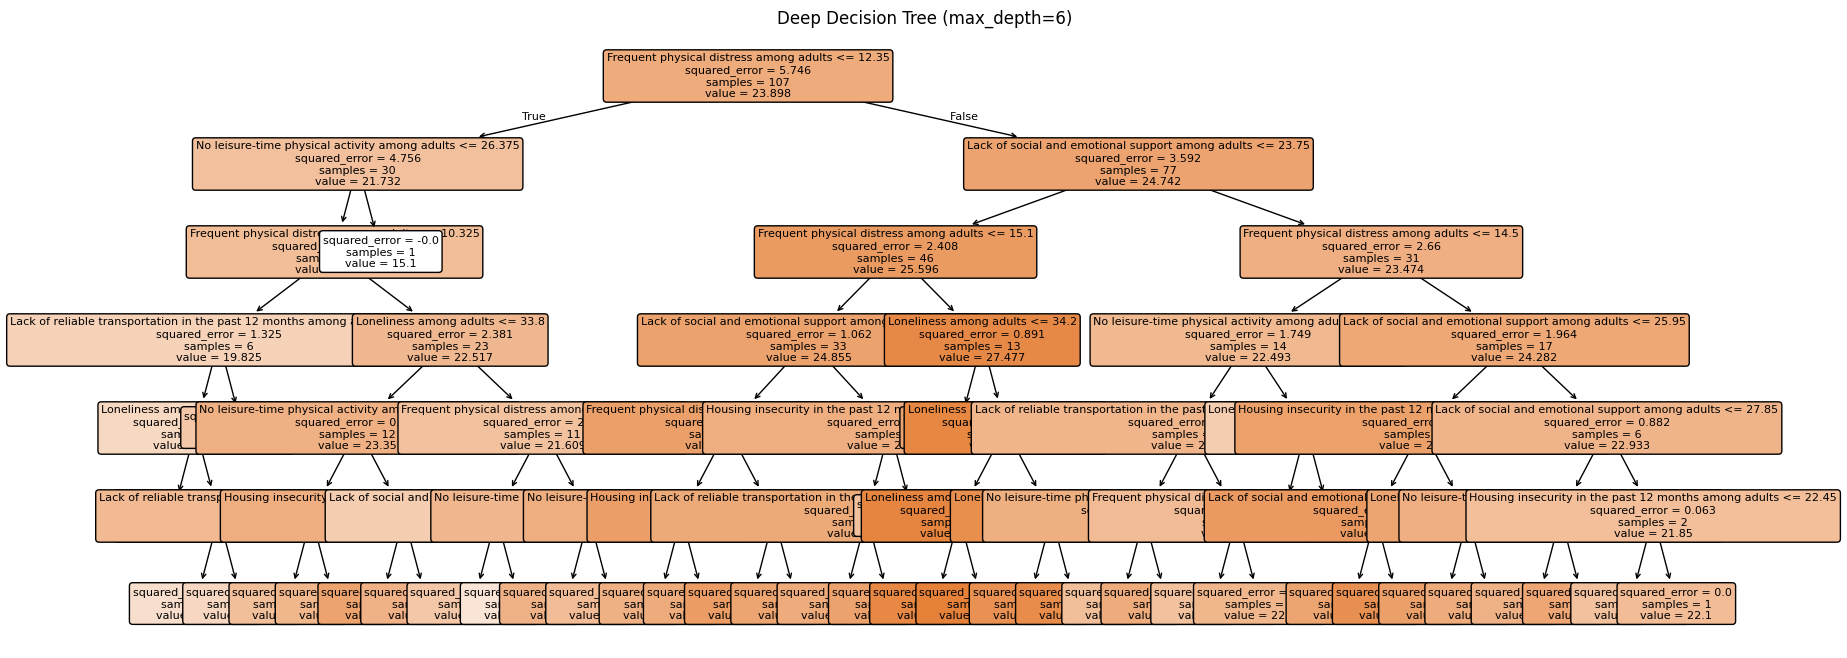

In [14]:
#plot the tree
plt.figure(figsize=(20, 8))
plot_tree(tree_deep, feature_names=X.columns.tolist(), filled=True, rounded=True, fontsize=8)
plt.title("Deep Decision Tree (max_depth=6)")
plt.show()

In addition to the predictors in the shallow tree, the deep tree split on three more features: loneliness, lack of reliable transportation, and housing insecurity. Food insecurity was not selected, likely because it was overshadowed by the other predictors. The deep tree has a lower MSE and higher R^2 than the shallow tree, but since the test set is so small, it is difficult to make definite claims about reliablity. Nonetheless, the MSE and R^2 values for both the shallow tree and deep tree are relatively close, which suggests that overfitting is not an issue.

##**Ensemble Models**

###**Random Forest**

In [15]:
#Shallow tree
rf_shallow = RandomForestRegressor(max_depth=3, random_state=42)
rf_shallow.fit(X_train, y_train)

y_pred_rf_shallow = rf_shallow.predict(X_test)
print("RF Shallow MSE:", mean_squared_error(y_test, y_pred_rf_shallow))
print("RF Shallow R2:", r2_score(y_test, y_pred_rf_shallow))


RF Shallow MSE: 1.7100650548430187
RF Shallow R2: 0.7087159156408361


Around 70.9% of the variance in depression prevalence can be explained by the shallow random forest model.

In [16]:
#Deep tree
rf_deep = RandomForestRegressor(max_depth=6, random_state=42)
rf_deep.fit(X_train, y_train)

y_pred_rf_deep = rf_deep.predict(X_test)
print("RF Deep MSE:", mean_squared_error(y_test, y_pred_rf_deep))
print("RF Deep R2:", r2_score(y_test, y_pred_rf_deep))

RF Deep MSE: 1.1965284052194993
RF Deep R2: 0.7961892268735432


The deep random forest performs better than the shallow random forest. Around 79.6% of the variance in depression prevalence can be explained by this model.

###**Gradient Boosting**

In [17]:
#Shallow tree
gb_shallow = GradientBoostingRegressor(max_depth=3, random_state=42)
gb_shallow.fit(X_train, y_train)

y_pred_gb_shallow = gb_shallow.predict(X_test)
print("GB Shallow MSE:", mean_squared_error(y_test, y_pred_gb_shallow))
print("GB Shallow R2:", r2_score(y_test, y_pred_gb_shallow))

GB Shallow MSE: 0.8839570176365292
GB Shallow R2: 0.849431102187659


In [18]:
#Deep tree
gb_deep = GradientBoostingRegressor(max_depth=6, random_state=42)
gb_deep.fit(X_train, y_train)

y_pred_gb_deep = gb_deep.predict(X_test)
print("GB Deep MSE:", mean_squared_error(y_test, y_pred_gb_deep))
print("GB Deep R2:", r2_score(y_test, y_pred_gb_deep))

GB Deep MSE: 1.5695138965726252
GB Deep R2: 0.7326567097799046


Of note, the deep gradient boosting model has a higher MSE and lower R^2 than the shallow one, likely due to overfitting.

##**Model Evaluation**

| Model                     | MSE   | R^2   |
|---------------------------|-------|-------|
| Shallow Decision Tree     | 2.516 | 0.571 |
| Deep Decision Tree        | 2.354 | 0.599 |
| Shallow Random Forest     | 1.710 | 0.709 |
| Deep Random Forest        | 1.197 | 0.796 |
| Shallow Gradient Boosting | 0.884 | 0.849 |
| Deep Gradient Boosting    | 1.570 | 0.733 |

A comparison of MSE and R^2 values across the six models shows that the best model is shallow gradient boosting. This model has the lowest MSE and highest R^2. Around 84.9% of the variance in depression prevalence among adults can be explained by the model. Taking the square root of the MSE, 0.88, the model's predictions of depression prevalence are off by an average of only 0.94 percentage points.


To visualize the comparison, I plotted the actual and predicted
values for the best models in each category (decision tree, random forest, gradient boosting).

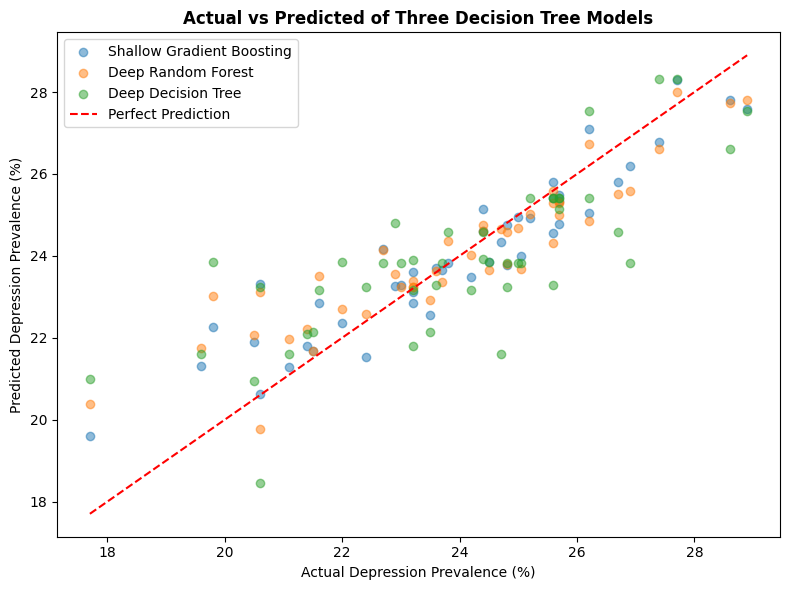

In [19]:
#Plotting actual vs. predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_gb_shallow, alpha=0.5, label="Shallow Gradient Boosting")
plt.scatter(y_test, y_pred_rf_deep, alpha=0.5, label="Deep Random Forest")
plt.scatter(y_test, y_pred_deep, alpha = 0.5, label = "Deep Decision Tree" )
plt.title("Actual vs Predicted of Three Decision Tree Models", fontweight = "bold")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Depression Prevalence (%)")
plt.ylabel("Predicted Depression Prevalence (%)")
plt.legend()
plt.tight_layout()
plt.show()



The plot confirms that shallow gradient boosting is the best model for predicting depression prevalence. Most points cluster around the perfect prediction line, and it has the least spread among the three models.

##**Feature Importance of Shallow Gradient Boosting Model**

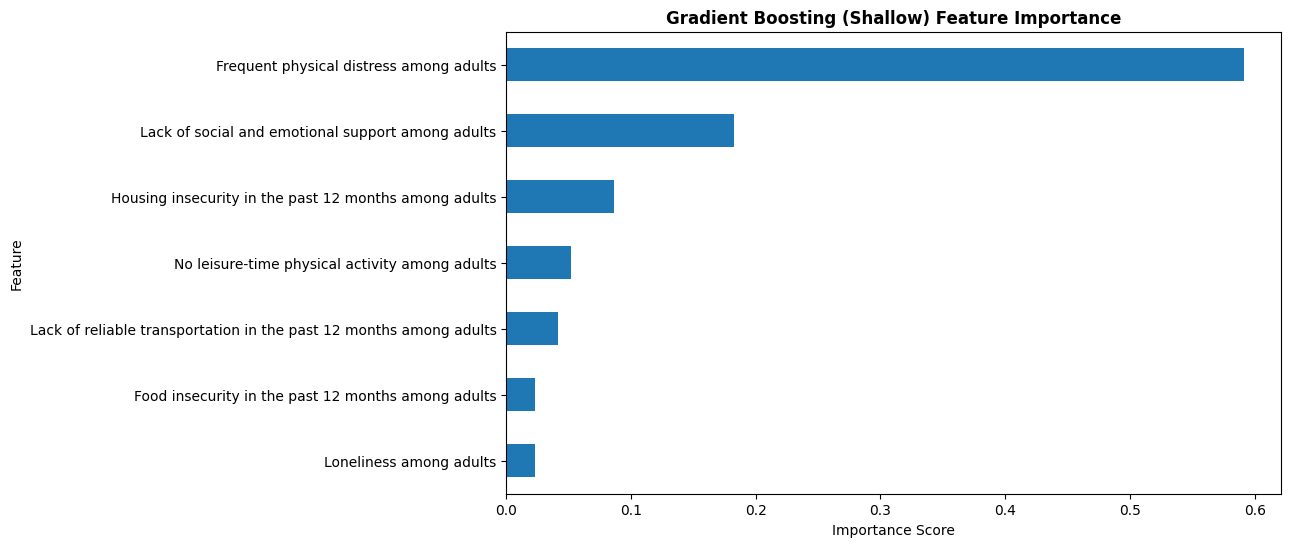

In [20]:
feature_importance_gb = pd.Series(gb_shallow.feature_importances_, index=X.columns)
feature_importance_gb.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Gradient Boosting (Shallow) Feature Importance", fontweight = "bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

The top three most important features for the shallow gradient boosting model are:


1.   Frequent physical distress among adults
2.   Lack of social and emotional support among adults
3.   Housing insecurity in the past 12 months among adults


The prevalence rate of frequent physical distress among adults is a dominant predictor, with an importance score above 0.5. Its importance suggests that there is a close link between physical and mental health in DMV counties surveyed in 2023.

##**Final Reflection**

The shallow gradient boosting model performs best because it has the lowest MSE and highest R^2 of all six models evaluated. However, the easiest model to interpret and explain is the shallow decision tree. This model only splits on three predictors, and its prediction paths are easily visualized.

In a real-world setting, I would choose the  shallow decision tree because it identifies the strongest three predictors of depression prevalence, which is helpful to policymakers seeking to mitigate the top risk factors associated with the condition.

Dataset size was a limitation in this project. For a real-world application, I would use a larger dataset, either by adding more variables, like sleep quality and lack of health insurance, or examining data on a more granular geographic level, such as by city or census tract.